In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

PURPLE_MAIN = "#A87FD4"
PURPLE_LIGHT = "#E1D3FB"

ISIC_PATH = Path("/Users/federico/Desktop/progetto VIS/5. altri bias/isic2018_artifacts_light/merged/07_isic_artifacts.csv")
df_isic = pd.read_csv(ISIC_PATH)

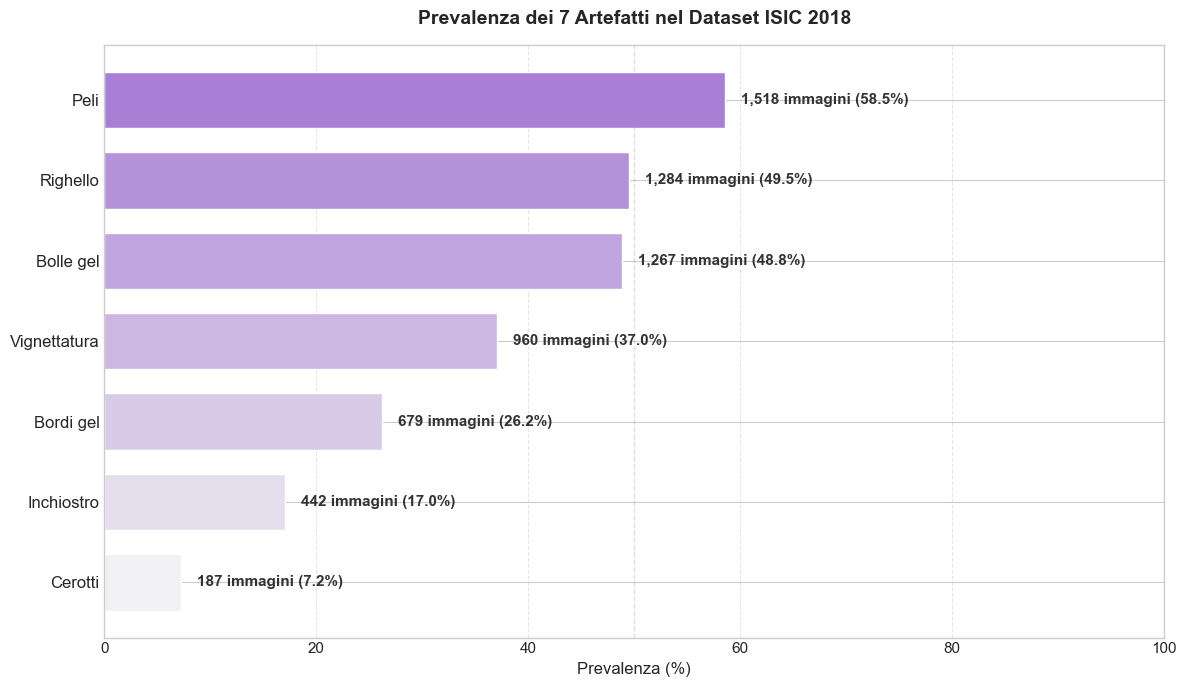

In [5]:
artifact_cols = ["dark_corner", "hair", "gel_border", "gel_bubble", "ruler", "ink", "patches"]
artifact_names = ["Vignettatura", "Peli", "Bordi gel", "Bolle gel", "Righello", "Inchiostro", "Cerotti"]

fig, ax = plt.subplots(figsize=(12, 7))

prevalence = df_isic[artifact_cols].sum().sort_values(ascending=True)
prevalence_pct = prevalence / len(df_isic) * 100

colors = sns.light_palette(PURPLE_MAIN, n_colors=len(prevalence), reverse=False)

bars = ax.barh(range(len(prevalence)), prevalence_pct.values, color=colors, edgecolor='white', height=0.7)

ax.set_yticks(range(len(prevalence)))
ax.set_yticklabels([artifact_names[artifact_cols.index(c)] for c in prevalence.index], fontsize=12)

ax.set_xlabel("Prevalenza (%)", fontsize=12)
ax.set_title("Prevalenza dei 7 Artefatti nel Dataset ISIC 2018", fontsize=14, fontweight="bold", pad=15)

for i, (val, pct) in enumerate(zip(prevalence.values, prevalence_pct.values)):
    ax.text(pct + 1.5, i, f"{int(val):,} immagini ({pct:.1f}%)", 
            va='center', fontsize=11, fontweight='bold', color='#333')

ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.axvline(50, color=PURPLE_MAIN, linestyle='--', linewidth=1, alpha=0.3)

ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

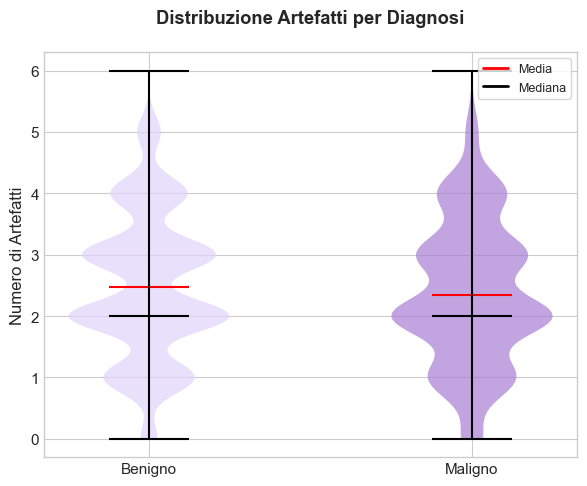

In [6]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 5))

violin_data = [
    df_isic[df_isic['diagnosis_binary'] == 'benign']['artifact_count'],
    df_isic[df_isic['diagnosis_binary'] == 'malignant']['artifact_count']
]

labels = ['Benigno', 'Maligno']
colors_box = [PURPLE_LIGHT, PURPLE_MAIN]

parts = ax.violinplot(
    violin_data,
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
    showextrema=True
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_box[i])
    pc.set_alpha(0.7)

parts['cmeans'].set_color('red')
parts['cmedians'].set_color('black')
parts['cbars'].set_color('black')
parts['cmins'].set_color('black')
parts['cmaxes'].set_color('black')

ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_ylabel('Numero di Artefatti', fontsize=12)
ax.set_title(
    'Distribuzione Artefatti per Diagnosi\n',
    fontweight='bold'
)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Media'),
    Line2D([0], [0], color='black', lw=2, label='Mediana')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True, edgecolor='#ccc')

plt.tight_layout()
plt.show()